In [12]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers, callbacks, utils
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("cleaned_dataset_taiwan_2months.csv")
df = df.sort_values('date')
df.head()

,date,sitename,county,aqi,status,so2,co,o3,pm10,pm2.5,no2,nox,no,siteid
125913,2024-07-01 00:00:00,Xindian,New Taipei City,36.0,Good,0.9,0.16,11.9,25.0,10.0,4.7,5.5,0.8,4
125851,2024-07-01 00:00:00,Banqiao,New Taipei City,22.0,Good,0.5,0.34,8.4,21.0,6.0,12.6,14.9,2.2,6
125852,2024-07-01 00:00:00,Xinzhuang,New Taipei City,28.0,Good,0.5,0.29,10.9,20.0,8.0,9.0,9.3,0.3,7
125853,2024-07-01 00:00:00,Cailiao,New Taipei City,33.0,Good,0.9,0.39,6.8,17.0,9.0,16.7,18.3,1.6,8
125854,2024-07-01 00:00:00,Linkou,New Taipei City,19.0,Good,1.2,0.17,8.0,10.0,8.0,8.7,10.3,1.5,9


In [3]:
features=['so2','co','o3','pm2.5','pm10','no2','nox','no']

status=['aqi']
X=df[features]
y=df[status]  


In [4]:
unique_dates = df['date'].unique()
split_idx = int(len(unique_dates) * 0.8)
train_dates = unique_dates[:split_idx]

df_train = df[df['date'].isin(train_dates)].copy()
df_test = df[~df['date'].isin(train_dates)].copy()

In [5]:
scaler = StandardScaler()
df_train[features] = scaler.fit_transform(df_train[features])
df_test[features] = scaler.transform(df_test[features])

def create_sequences_by_station(dataframe, feature_cols, window_size=24):
    X_seq, y_seq = [], []
    # Group by station name to keep timelines fully isolated
    for station, group in dataframe.groupby('sitename'):
        group_sorted = group.sort_values('date')
        group_features = group_sorted[feature_cols].values
        group_targets = group_sorted['aqi'].values
        
        if len(group_sorted) > window_size:
            for i in range(len(group_sorted) - window_size):
                X_seq.append(group_features[i : (i + window_size)])
                y_seq.append(group_targets[i + window_size])
                
    return np.array(X_seq), np.array(y_seq)

# Build valid 3D shapes representing (Samples, 24 Hours, 8 Features)
X_train_seq, y_train_seq = create_sequences_by_station(df_train, features, window_size=24)
X_test_seq, y_test_seq = create_sequences_by_station(df_test, features, window_size=24)

print("Clean Train Sequence Shape:", X_train_seq.shape)
print("Clean Test Sequence Shape:", X_test_seq.shape)

Clean Train Sequence Shape: (98590, 24, 8)
Clean Test Sequence Shape: (23244, 24, 8)


In [6]:
model = tf.keras.Sequential([
# Input shape: (Time Steps, Features)
    layers.Input(shape=(24, 8)), 
    
    # First GRU layer 
    layers.GRU(128, return_sequences=True),
    layers.BatchNormalization(), 
    layers.Dropout(0.4),
    

    # Third GRU layer
    layers.GRU(64),
    layers.BatchNormalization(),
    layers.Dropout(0.2),


    # Output Layer
    layers.Dense(1, activation='linear')
])

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mae',
    metrics=['mae','mse'

    ]
)

In [ ]:
# callback for saving checkpoint and early stop
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath='best_model_svm_regressor.keras', monitor='val_loss', save_best_only=True),
    reduce_lr
]

In [9]:
model.fit(
X_train_seq, y_train_seq,
epochs=100,
batch_size=256,
shuffle=True,
validation_split=0.2,
verbose=1,
callbacks=my_callbacks
)#training nn

Epoch 1/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 38s 108ms/step - loss: 28.7249 - mae: 28.7249 - mse: 980.2989 - val_loss: 27.1566 - val_mae: 27.1566 - val_mse: 874.8486 - learning_rate: 5.0000e-04
Epoch 2/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 31s 101ms/step - loss: 20.9686 - mae: 20.9686 - mse: 559.1876 - val_loss: 14.4848 - val_mae: 14.4848 - val_mse: 264.5479 - learning_rate: 5.0000e-04
Epoch 3/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 32s 102ms/step - loss: 7.6340 - mae: 7.6340 - mse: 107.7468 - val_loss: 8.0039 - val_mae: 8.0039 - val_mse: 80.8883 - learning_rate: 5.0000e-04
Epoch 4/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 31s 101ms/step - loss: 3.5027 - mae: 3.5027 - mse: 25.6945 - val_loss: 4.5061 - val_mae: 4.5061 - val_mse: 32.4237 - learning_rate: 5.0000e-04
Epoch 5/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 31s 102ms/step - loss: 3.1766 - mae: 3.1766 - mse: 21.5172 - val_loss: 2.8344 - val_mae: 2.8344 - val_mse: 15.9486 - learning_rate: 5.0000e-04
Epoch 6/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 32s 104ms/step - loss: 2.9

In [15]:
best_model=tf.keras.models.load_model("best_model_svm_regressor).keras")
nn_pseudo_labels = best_model.predict(X_train_seq)
y_pseudo_train = nn_pseudo_labels.flatten()


X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)
X_test_flat_sequences = X_test_seq.reshape(X_test_seq.shape[0], -1)


# Train SVM on the extracted features
svm_model = LinearSVR(dual=False,max_iter=2000,random_state=20, loss="squared_epsilon_insensitive")
svm_model.fit(X_train_flat, y_pseudo_train)

# Evaluate SVM
y_pred_svm = svm_model.predict(X_test_flat_sequences)
print("\n--- Corrected Distilled Random Forest Regression Performance ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_seq, y_pred_svm):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_seq, y_pred_svm):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test_seq, y_pred_svm)):.4f}")
print(f"R-squared (R2) Variance Score: {r2_score(y_test_seq, y_pred_svm):.4f}")

3081/3081 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step

--- Corrected Distilled Random Forest Regression Performance ---
Mean Absolute Error (MAE): 3.5533
Mean Squared Error (MSE): 26.4663
Root Mean Squared Error (RMSE): 5.1445
R-squared (R2) Variance Score: 0.8833


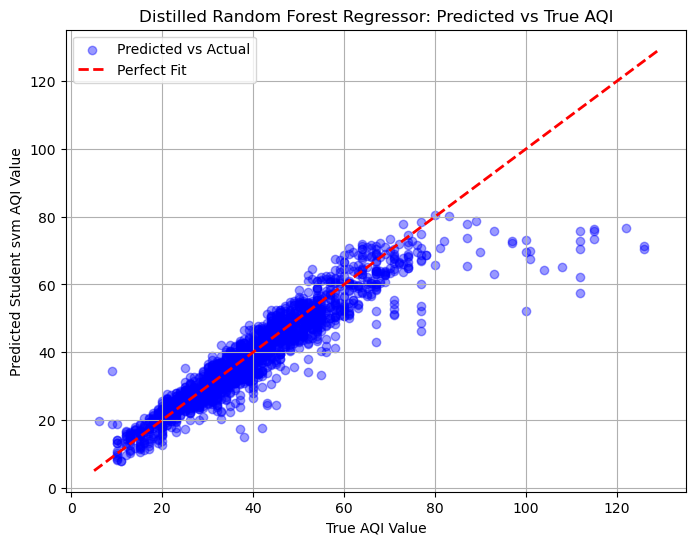

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_seq[:2000], y_pred_svm[:2000], alpha=0.4, color='b', label='Predicted vs Actual')

# Plot accurate perfect diagonal trendline boundary
perfect_line = [min(y_test_seq), max(y_test_seq)]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.xlabel('True AQI Value')
plt.ylabel('Predicted Student svm AQI Value')
plt.title('Distilled Random Forest Regressor: Predicted vs True AQI')
plt.legend()
plt.grid(True)
plt.savefig('regression_fit_perf.png')

In [17]:
import joblib

# 1. Save the Trained Student Random Forest Regressor
# Using compress=3 reduces file size significantly on your disk
joblib.dump(svm_model, 'distilled_SVM_regressor.pkl', compress=3)
print("✅ Student Random Forest Model successfully saved as 'distilled_random_forest_regressor.pkl'")

# 2. Save the Standard Scaler (Crucial for transforming new deployment inputs correctly)
joblib.dump(scaler, 'aqi_scaler_SVM.pkl')
print("✅ Feature Scaler successfully saved as 'aqi_scaler.pkl'")

# 3. Save the Trained Teacher GRU Deep Learning Model
# Keras models should be saved in native .keras format
model.save('teacher_gru_regressor.keras')
print("✅ Teacher GRU Deep Learning Model successfully saved as 'teacher_gru_regressor.keras'")

✅ Student Random Forest Model successfully saved as 'distilled_random_forest_regressor.pkl'
✅ Feature Scaler successfully saved as 'aqi_scaler.pkl'
✅ Teacher GRU Deep Learning Model successfully saved as 'teacher_gru_regressor.keras'
